In [12]:
import uproot

# # You can load them together like this:
# events = uproot.concatenate([
#     "Root_Files/ttbar_ATLAS_PileUp_Run2_events.root:Delphes", 
#     "Root_Files/ttbar_ATLAS_PileUp_Run2_events_1.root:Delphes"
# ])

In [13]:
file = uproot.open("/home/aegis/Titan0/madgraph/MG5_aMC_v3_7_0/bin/ttbar_validation/Events/Root_Files/ttbar_ATLAS_default_events.root")
tree = file["Delphes"]

print(tree.keys())

['Event', 'Event/Event.fUniqueID', 'Event/Event.fBits', 'Event/Event.Number', 'Event/Event.ReadTime', 'Event/Event.ProcTime', 'Event/Event.ProcessID', 'Event/Event.MPI', 'Event/Event.Weight', 'Event/Event.CrossSection', 'Event/Event.CrossSectionError', 'Event/Event.Scale', 'Event/Event.AlphaQED', 'Event/Event.AlphaQCD', 'Event/Event.ID1', 'Event/Event.ID2', 'Event/Event.X1', 'Event/Event.X2', 'Event/Event.ScalePDF', 'Event/Event.PDF1', 'Event/Event.PDF2', 'Event_size', 'Weight', 'Weight/Weight.fUniqueID', 'Weight/Weight.fBits', 'Weight/Weight.Weight', 'Weight_size', 'Particle', 'Particle/Particle.fUniqueID', 'Particle/Particle.fBits', 'Particle/Particle.PID', 'Particle/Particle.Status', 'Particle/Particle.IsPU', 'Particle/Particle.M1', 'Particle/Particle.M2', 'Particle/Particle.D1', 'Particle/Particle.D2', 'Particle/Particle.Charge', 'Particle/Particle.Mass', 'Particle/Particle.E', 'Particle/Particle.Px', 'Particle/Particle.Py', 'Particle/Particle.Pz', 'Particle/Particle.P', 'Particle/

In [29]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import os

# ============================================================
# 1. CUTFLOW TRACKER
# ============================================================
class CutflowTracker:
    def __init__(self):
        self.steps = []
        self.raw_counts = {}
        self.weighted_counts = {}

    def update(self, step_name, events):
        if step_name not in self.steps: self.steps.append(step_name)
        n_raw = len(events)
        w_sum = ak.sum(np.ones(len(events))) if len(events) > 0 else 0.0
        self.raw_counts[step_name] = self.raw_counts.get(step_name, 0) + n_raw
        self.weighted_counts[step_name] = self.weighted_counts.get(step_name, 0.0) + w_sum

    def summary(self):
        """Returns a dictionary of the raw counts for the all_results dict."""
        return {step: self.raw_counts[step] for step in self.steps}

    def save_csv(self, process_name, output_dir):
        data = []
        if not self.steps: return
        initial_w = self.weighted_counts.get(self.steps[0], 1.0)
        if initial_w == 0: initial_w = 1.0 
        prev_w = initial_w

        for step in self.steps:
            raw = self.raw_counts[step]
            weighted = self.weighted_counts[step]
            abs_eff = (weighted / initial_w) * 100
            rel_eff = (weighted / prev_w) * 100 if prev_w > 0 else 0
            
            data.append({
                "Step": step, "Raw Events": raw, "Weighted Yield": weighted,
                "Absolute Eff (%)": f"{abs_eff:.2f}", "Relative Eff (%)": f"{rel_eff:.2f}"
            })
            prev_w = weighted
            
        df = pd.DataFrame(data)
        os.makedirs(output_dir, exist_ok=True)
        df.to_csv(os.path.join(output_dir, f"cutflow_{process_name}.csv"), index=False)
        print(f"Saved cutflow for {process_name}")

# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================
def delta_r(eta1, phi1, eta2, phi2):
    """Calculates angular distance ΔR with proper phi wrapping."""
    deta = eta1 - eta2
    dphi = np.abs(phi1 - phi2)
    dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    return np.sqrt(deta**2 + dphi**2)

def apply_overlap_removal(events):
    """
    Applies overlap removal criteria using purely flat parallel arrays.
    """
    jet_pt     = events["valid_jet_pt"]
    jet_eta    = events["valid_jet_eta"]
    jet_phi    = events["valid_jet_phi"]
    jet_trk    = events["valid_jet_trk"] 
    jet_btag   = events["valid_jet_btag"]
    jet_tautag = events["valid_jet_tautag"]

    ele_pt  = events["valid_elec_pt"]
    ele_eta = events["valid_elec_eta"]
    ele_phi = events["valid_elec_phi"]

    mu_pt   = events["valid_muon_pt"]
    mu_eta  = events["valid_muon_eta"]
    mu_phi  = events["valid_muon_phi"]

    # 1. JET-ELECTRON OR: Remove jet if ΔR(jet, e) < 0.2
    je_eta_j, je_eta_e = ak.unzip(ak.cartesian((jet_eta, ele_eta), nested=True))
    je_phi_j, je_phi_e = ak.unzip(ak.cartesian((jet_phi, ele_phi), nested=True))
    
    dR_je = delta_r(je_eta_j, je_phi_j, je_eta_e, je_phi_e)
    jet_pass_e = ak.all(dR_je >= 0.2, axis=-1)
    
    jet_pt, jet_eta, jet_phi = jet_pt[jet_pass_e], jet_eta[jet_pass_e], jet_phi[jet_pass_e]
    jet_trk, jet_btag, jet_tautag = jet_trk[jet_pass_e], jet_btag[jet_pass_e], jet_tautag[jet_pass_e]

    # 2. JET-MUON OR: Remove jet if ΔR(jet, mu) < 0.4 AND jet tracks < 3
    jm_eta_j, jm_eta_m = ak.unzip(ak.cartesian((jet_eta, mu_eta), nested=True))
    jm_phi_j, jm_phi_m = ak.unzip(ak.cartesian((jet_phi, mu_phi), nested=True))
    
    dR_jm = delta_r(jm_eta_j, jm_phi_j, jm_eta_m, jm_phi_m)
    jet_near_mu = ak.any(dR_jm < 0.4, axis=-1)
    
    jet_pass_mu = ~(jet_near_mu & (jet_trk < 3))
    
    surv_jet_pt, surv_jet_eta, surv_jet_phi = jet_pt[jet_pass_mu], jet_eta[jet_pass_mu], jet_phi[jet_pass_mu]
    surv_jet_btag, surv_jet_tautag = jet_btag[jet_pass_mu], jet_tautag[jet_pass_mu]

    # 3. ELECTRON-JET OR: Remove e if ΔR(e, surviving_jet) < 0.4
    ej_eta_e, ej_eta_j = ak.unzip(ak.cartesian((ele_eta, surv_jet_eta), nested=True))
    ej_phi_e, ej_phi_j = ak.unzip(ak.cartesian((ele_phi, surv_jet_phi), nested=True))
    
    dR_ej = delta_r(ej_eta_e, ej_phi_e, ej_eta_j, ej_phi_j)
    ele_pass_j = ak.all(dR_ej >= 0.4, axis=-1)
    
    surv_ele_pt, surv_ele_eta, surv_ele_phi = ele_pt[ele_pass_j], ele_eta[ele_pass_j], ele_phi[ele_pass_j]

    # 4. MUON-JET OR: Remove mu if ΔR(mu, surviving_jet) < 0.4
    mj_eta_m, mj_eta_j = ak.unzip(ak.cartesian((mu_eta, surv_jet_eta), nested=True))
    mj_phi_m, mj_phi_j = ak.unzip(ak.cartesian((mu_phi, surv_jet_phi), nested=True))
    
    dR_mj = delta_r(mj_eta_m, mj_phi_m, mj_eta_j, mj_phi_j)
    mu_pass_j = ak.all(dR_mj >= 0.4, axis=-1)
    
    surv_mu_pt, surv_mu_eta, surv_mu_phi = mu_pt[mu_pass_j], mu_eta[mu_pass_j], mu_phi[mu_pass_j]

    # 5. Save the cleaned arrays back to the event
    events["post_OR_jet_pt"]     = surv_jet_pt
    events["post_OR_jet_eta"]    = surv_jet_eta
    events["post_OR_jet_phi"]    = surv_jet_phi
    events["post_OR_jet_btag"]   = surv_jet_btag
    events["post_OR_jet_tautag"] = surv_jet_tautag

    events["post_OR_elec_pt"]  = surv_ele_pt
    events["post_OR_elec_eta"] = surv_ele_eta
    events["post_OR_elec_phi"] = surv_ele_phi

    events["post_OR_muon_pt"]  = surv_mu_pt
    events["post_OR_muon_eta"] = surv_mu_eta
    events["post_OR_muon_phi"] = surv_mu_phi

    return events

# ============================================================
# 3. EVENT PRESELECTION
# ============================================================
def apply_preselection(events, tracker):
    if len(events) == 0: return events
    tracker.update("Initial Raw Batch", events)
    # Add weights later
    
    # Prevent shape mismatch for MET later
    try:
        events["met_standard_pt"]  = events["MissingET/MissingET.MET"][:, 0]
        events["met_standard_phi"] = events["MissingET/MissingET.Phi"][:, 0]
    except IndexError:
        events["met_standard_pt"]  = events["MissingET/MissingET.MET"]
        events["met_standard_phi"] = events["MissingET/MissingET.Phi"]

    # ====================================================================
    # 1. KINEMATIC SELECTION
    # ====================================================================

    events["valid_jet_pt"]  = events["Jet/Jet.PT"]
    events["valid_jet_eta"] = events["Jet/Jet.Eta"]
    events["valid_jet_phi"] = events["Jet/Jet.Phi"]
    events["valid_jet_trk"] = events["Jet/Jet.NCharged"]
    events["valid_jet_btag"] = events["Jet/Jet.BTag"]
    events["valid_jet_tautag"] = events["Jet/Jet.TauTag"]

    raw_ele_pt = events["Electron/Electron.PT"]
    raw_ele_eta = events["Electron/Electron.Eta"]
    raw_ele_phi = events["Electron/Electron.Phi"]

    ele_base_mask = (raw_ele_pt > 7) & (np.abs(raw_ele_eta) < 2.5)

    events["valid_elec_pt"]  = raw_ele_pt[ele_base_mask]
    events["valid_elec_eta"] = raw_ele_eta[ele_base_mask]
    events["valid_elec_phi"] = raw_ele_phi[ele_base_mask]

    raw_mu_pt = events["Muon/Muon.PT"]
    raw_mu_eta = events["Muon/Muon.Eta"]
    raw_mu_phi = events["Muon/Muon.Phi"]

    mu_base_mask = (raw_mu_pt > 7) & (np.abs(raw_mu_eta) < 2.5)
    events["valid_muon_pt"]  = raw_mu_pt[mu_base_mask]
    events["valid_muon_eta"] = raw_mu_eta[mu_base_mask]
    events["valid_muon_phi"] = raw_mu_phi[mu_base_mask]

    events = apply_overlap_removal(events)
    tracker.update("Overlap Removal", events)
    if len(events) == 0: return events

    eta_mask = np.abs(events["post_OR_jet_eta"]) < 2.8
    pt_mask = events["post_OR_jet_pt"] > 30
    sig_jet_mask = eta_mask & pt_mask

    events["signal_jet_pt"]  = events["post_OR_jet_pt"][sig_jet_mask]
    events["signal_jet_eta"] = events["post_OR_jet_eta"][sig_jet_mask]
    events["signal_jet_phi"] = events["post_OR_jet_phi"][sig_jet_mask]
    events["signal_jet_btag"] = events["post_OR_jet_btag"][sig_jet_mask]
    events["signal_jet_tautag"] = events["post_OR_jet_tautag"][sig_jet_mask]

    has_at_least_2 = ak.num(events["signal_jet_pt"]) >= 2
    events = events[has_at_least_2]
    if len(events) == 0: return events
    events = events[events["signal_jet_pt"][:, 0] > 250]

    tracker.update("Signal Jet Kinematic Selection", events)

    # ====================================================================
    # 4. LARGE-R JET REQUIREMENT 
    # ====================================================================
    ljet_pt = events["FatJet/FatJet.PT"]
    events = events[ak.num(ljet_pt) >= 2]
    
    tracker.update("Large-R Jet >= 2", events)
    if len(events) == 0: return events

    # ====================================================================
    # 5. B-JET VETO / TAGGING
    # ====================================================================
    n_bjets = ak.sum(events["valid_jet_btag"] == 1, axis=1)
    events["n_bjets"] = n_bjets
    events = events[n_bjets <= 1]

    tracker.update("B-jet Veto", events)
    if len(events) == 0: return events

    # ====================================================================
    # 6. SIGNAL LEPTON REQUIREMENTS (Post-OR)
    # ====================================================================
    ele_eta_abs = np.abs(events["post_OR_elec_eta"])
    ele_sig_mask = (events["post_OR_elec_pt"] > 7) & \
                   (ele_eta_abs < 2.5) & \
                   ~((ele_eta_abs > 1.37) & (ele_eta_abs < 1.52))
    
    events["signal_elec_pt"]  = events["post_OR_elec_pt"][ele_sig_mask]
    events["signal_elec_eta"] = events["post_OR_elec_eta"][ele_sig_mask]
    events["signal_elec_phi"] = events["post_OR_elec_phi"][ele_sig_mask]

    mu_sig_mask = (events["post_OR_muon_pt"] > 7) & (np.abs(events["post_OR_muon_eta"]) < 2.5)

    events["signal_muon_pt"]  = events["post_OR_muon_pt"][mu_sig_mask]
    events["signal_muon_eta"] = events["post_OR_muon_eta"][mu_sig_mask]
    events["signal_muon_phi"] = events["post_OR_muon_phi"][mu_sig_mask]

    # ====================================================================
    # 7. MET REBUILDING (Excluding Muons)
    # ====================================================================
    sum_j_px = ak.sum(events["signal_jet_pt"] * np.cos(events["signal_jet_phi"]), axis=1)
    sum_j_py = ak.sum(events["signal_jet_pt"] * np.sin(events["signal_jet_phi"]), axis=1)

    sum_e_px = ak.sum(events["signal_elec_pt"] * np.cos(events["signal_elec_phi"]), axis=1)
    sum_e_py = ak.sum(events["signal_elec_pt"] * np.sin(events["signal_elec_phi"]), axis=1)

    sum_mu_px = ak.sum(events["signal_muon_pt"] * np.cos(events["signal_muon_phi"]), axis=1)
    sum_mu_py = ak.sum(events["signal_muon_pt"] * np.sin(events["signal_muon_phi"]), axis=1)

    soft_px = events["met_standard_pt"] * np.cos(events["met_standard_phi"]) - sum_j_px - sum_e_px - sum_mu_px
    soft_py = events["met_standard_pt"] * np.sin(events["met_standard_phi"]) - sum_j_py - sum_e_py - sum_mu_py

    # --- 1. THE TRIGGER PROXY (Standard Full MET) ---
    std_met_px = -(sum_j_px + sum_e_px + sum_mu_px + soft_px)
    std_met_py = -(sum_j_py + sum_e_py + sum_mu_py + soft_py)
    events["met_standard_pt"] = np.sqrt(std_met_px**2 + std_met_py**2)

    # --- 2. YOUR ANALYSIS MET (Muons treated as invisible) ---
    met_px = -(sum_j_px + sum_e_px + soft_px)
    met_py = -(sum_j_py + sum_e_py + soft_py)
    events["met_recalc_pt"]  = np.sqrt(met_px**2 + met_py**2)
    events["met_recalc_phi"] = np.arctan2(met_py, met_px)

    # ====================================================================
    # 7.5 TRIGGER PROXY CUT
    # ====================================================================
    # Force the event to have enough REAL missing energy to fire the MET trigger
    events = events[events["met_standard_pt"] > 250]
    tracker.update("MET Rebuilding", events)

    # ====================================================================
    # 8. FINAL VARIABLES & dPhi CUT
    # ====================================================================
    events["ht"]    = ak.sum(events["signal_jet_pt"], axis=1)
    events["n_mu"]  = ak.num(events["signal_muon_pt"])
    events["n_ele"] = ak.num(events["signal_elec_pt"])
    events["n_tau"] = ak.sum(events["post_OR_jet_tautag"] == 1, axis=1)
    # Tau Veto
    events = events[events["n_tau"] == 0]
    tracker.update("Tau Veto", events)
    dphi = np.abs(events["signal_jet_phi"] - events["met_recalc_phi"])
    dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    pass_dphi = ak.any(dphi < 2.0, axis=1)
    events = events[pass_dphi]
    tracker.update("dPhi(Jet, MET) < 2.0", events)
    if len(events) == 0: return events

    # ====================================================================
    # 9. ABCD VARIABLES (pT_bal and dPhi_j1_j2)
    # ====================================================================
    dphi_jet_met = np.abs(events["signal_jet_phi"] - events["met_recalc_phi"])
    dphi_jet_met = ak.where(dphi_jet_met > np.pi, 2 * np.pi - dphi_jet_met, dphi_jet_met)

    # Find the indices of the jet closest (j1) and farthest (j2) to MET
    idx_j1 = ak.argmin(dphi_jet_met, axis=1, keepdims=True)
    idx_j2 = ak.argmax(dphi_jet_met, axis=1, keepdims=True)

    # Extract pT and Phi for j1 and j2. 
    # ak.flatten reduces them back to 1D arrays for straightforward NumPy math
    pt_j1  = ak.flatten(events["signal_jet_pt"][idx_j1])
    phi_j1 = ak.flatten(events["signal_jet_phi"][idx_j1])
    
    pt_j2  = ak.flatten(events["signal_jet_pt"][idx_j2])
    phi_j2 = ak.flatten(events["signal_jet_phi"][idx_j2])

    # 1. Calculate pT balance (vector sum magnitude / scalar sum)
    px_1, py_1 = pt_j1 * np.cos(phi_j1), pt_j1 * np.sin(phi_j1)
    px_2, py_2 = pt_j2 * np.cos(phi_j2), pt_j2 * np.sin(phi_j2)
    
    num = np.sqrt((px_1 + px_2)**2 + (py_1 + py_2)**2)
    den = pt_j1 + pt_j2
    events["pt_bal"] = num / den

    # 2. Calculate azimuthal separation between j1 and j2
    dphi_j1_j2 = np.abs(phi_j1 - phi_j2)
    dphi_j1_j2 = ak.where(dphi_j1_j2 > np.pi, 2 * np.pi - dphi_j1_j2, dphi_j1_j2)
    events["dphi_j1_j2"] = dphi_j1_j2

    return events


# ============================================================
# 4. REGION SPLITTING
# ============================================================
def split_events(events):
    if len(events) == 0: return {}

    base_mask = (events["met_standard_pt"] > 250)
    kin_mask_sr = (events["met_recalc_pt"] > 600) & (events["ht"] > 600)
    kin_mask_cr_atlas = kin_mask_sr 
    kin_mask_mjrr_atlas = (events["met_recalc_pt"] > 250) & (events["met_recalc_pt"] <= 300) & (events["ht"] > 600)

    kin_mask_cr_ml = base_mask & ~kin_mask_sr

    def get_Z_window_events(evts, kin_mask):
        """Filters events for 2 muons, 0 b-jets, and applies the Z-mass window."""
        base_2L_mask = kin_mask & (evts["n_mu"] == 2) & (evts["n_bjets"] == 0) & (evts["n_ele"] == 0)
        ev_2L = evts[base_2L_mask]
        
        if len(ev_2L) == 0: return ev_2L
        
        mu1_pt, mu2_pt   = ev_2L["signal_muon_pt"][:, 0], ev_2L["signal_muon_pt"][:, 1]
        mu1_eta, mu2_eta = ev_2L["signal_muon_eta"][:, 0], ev_2L["signal_muon_eta"][:, 1]
        mu1_phi, mu2_phi = ev_2L["signal_muon_phi"][:, 0], ev_2L["signal_muon_phi"][:, 1]
        
        deta = mu1_eta - mu2_eta
        dphi = np.abs(mu1_phi - mu2_phi)
        dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
        
        mass_mumu = np.sqrt(2 * mu1_pt * mu2_pt * (np.cosh(deta) - np.cos(dphi)))
        return ev_2L[(mass_mumu >= 66) & (mass_mumu <= 116)]

    # ====================================================================
    # 3. REGION DICTIONARY
    # ====================================================================
    regions = {
        # --- SHARED SIGNAL REGIONS ---
        "SR": events[kin_mask_sr & (events["n_mu"] == 0) & (events["n_ele"] == 0) & (events["n_bjets"] <= 1)],

        # --- PARADIGM 1: ML EXTRAPOLATION (L-Shaped Boundary) ---
        "ML_CR_0L": events[kin_mask_cr_ml & (events["n_mu"] == 0) & (events["n_ele"] == 0) & (events["n_bjets"] <= 1)],
        "ML_CR_1L": events[kin_mask_cr_ml & (events["n_mu"] == 1) & (events["n_ele"] == 0) & (events["n_bjets"] == 0)],
        "ML_CR_1L1B": events[kin_mask_cr_ml & (events["n_mu"] == 1) & (events["n_ele"] == 0) & (events["n_bjets"] == 1)],
        "ML_CR_2L": get_Z_window_events(events, kin_mask_cr_ml),

        # --- PARADIGM 2: ATLAS PAPER CRs (Identical Phase Space to SR) ---
        "ATLAS_CR_1L": events[kin_mask_cr_atlas & (events["n_mu"] == 1) & (events["n_ele"] == 0) & (events["n_bjets"] == 0)],
        "ATLAS_CR_1L1B": events[kin_mask_cr_atlas & (events["n_mu"] == 1) & (events["n_ele"] == 0) & (events["n_bjets"] == 1)],
        "ATLAS_CR_2L": get_Z_window_events(events, kin_mask_cr_atlas),
        "ATLAS_CR_MJRR": events[kin_mask_mjrr_atlas & (events["n_mu"] == 0) & (events["n_ele"] == 0) & (events["n_bjets"] <= 1)]
    }

    return regions


In [ ]:
# ============================================================
# 5. MAIN EXECUTION
# ============================================================
FILES = {
    "ttbar_default": ["ttbar_ATLAS_default_events.root"],
    "ttbar_run2": ["ttbar_ATLAS_Run2_events.root"],
    "ttbar_pu": [
        "ttbar_ATLAS_PileUp_Run2_events.root",
        "ttbar_ATLAS_PileUp_Run2_events_1.root"
    ],
    "ttbar_pu_run2": [
        "ttbar_ATLAS_PileUp_Run2_events.root",
        "ttbar_ATLAS_PileUp_Run2_events_1.root"
    ],
    "bsm_default": ["1000_8_ATLAS_default_events.root"],
    "bsm_run2": ["1000_8_ATLAS_Run2_events.root"],
    "bsm_pu": ["1000_8_ATLAS_PileUp_Run2_events.root"],
    "bsm_pu_run2": ["1000_8_ATLAS_PileUp_Run2_events.root"]
}

branches_to_load = [
    "Jet/Jet.PT", "Jet/Jet.Eta", "Jet/Jet.Phi", "Jet/Jet.NCharged", "Jet/Jet.BTag", "Jet/Jet.TauTag",
    "Electron/Electron.PT", "Electron/Electron.Eta", "Electron/Electron.Phi",
    "Muon/Muon.PT", "Muon/Muon.Eta", "Muon/Muon.Phi",
    "FatJet/FatJet.PT",
    "MissingET/MissingET.MET", "MissingET/MissingET.Phi"
]

all_results = {}
OUTPUT_DIR = "Analysis_Output_ver2"

for tag, fnames in FILES.items():
    print(f"\nProcessing: {tag}")
    tracker = CutflowTracker()
    
    # --- THE FIX: Start with an empty dict, let it populate dynamically ---
    regions_total = {}

    # Format the list of file paths for uproot
    file_paths = [f"Root_Files/{fname}:Delphes" for fname in fnames]

    try:
        # Iterate by exactly 50,000 events at a time to prevent uproot from hanging
        for events_chunk in uproot.iterate(file_paths, filter_name=branches_to_load, library="ak", step_size=50000):

            # Standardize the Awkward Array Keys
            for full_name in branches_to_load:
                short_name = full_name.split('/')[-1]
                if short_name in events_chunk.fields and full_name not in events_chunk.fields:
                    events_chunk[full_name] = events_chunk[short_name]
            # print("Processing---")
            # Process the memory chunk
            events_chunk = apply_preselection(events_chunk, tracker)
            regions = split_events(events_chunk)

            # Append the surviving events to our total tally dynamically
            for r in regions:
                tracker.update(f"Region: {r}", regions[r])
                if len(regions[r]) > 0:
                    # If this region hasn't been seen yet, create an empty list for it
                    if r not in regions_total:
                        regions_total[r] = []
                    regions_total[r].append(regions[r])

    except Exception as e:
        print(f"Error loading {tag}: {e}")
        continue
    
    # Save results
    for r in regions_total:
        if len(regions_total[r]) > 0:
            # Concatenate all the small chunks of surviving events back into one array
            final_region_array = ak.concatenate(regions_total[r])
            
            save_path = os.path.join(OUTPUT_DIR, r)
            os.makedirs(save_path, exist_ok=True)
            file_name = os.path.join(save_path, f"{tag}.parquet")
            ak.to_parquet(final_region_array, file_name)

    all_results[tag] = {
        "regions": regions_total,
        "cutflow": tracker.summary()
    }
    
    tracker.save_csv(tag, OUTPUT_DIR)


Processing: ttbar_default
Processing---
Error loading ttbar_default: name 'apply_preselection' is not defined

Processing: ttbar_run2
Processing---
Error loading ttbar_run2: name 'apply_preselection' is not defined

Processing: ttbar_pu


KeyboardInterrupt: 

In [ ]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import os

# ============================================================
# 1. CUTFLOW TRACKER
# ============================================================
class CutflowTracker:
    def __init__(self):
        self.steps = []
        self.raw_counts = {}
        self.weighted_counts = {}

    def update(self, step_name, events):
        if step_name not in self.steps: self.steps.append(step_name)
        n_raw = len(events)
        w_sum = ak.sum(np.ones(len(events))) if len(events) > 0 else 0.0
        self.raw_counts[step_name] = self.raw_counts.get(step_name, 0) + n_raw
        self.weighted_counts[step_name] = self.weighted_counts.get(step_name, 0.0) + w_sum

    def summary(self):
        return {step: self.raw_counts[step] for step in self.steps}

    def save_csv(self, process_name, output_dir):
        data = []
        if not self.steps: return
        initial_w = max(self.weighted_counts.get(self.steps[0], 1.0), 1.0)
        prev_w = initial_w

        for step in self.steps:
            raw = self.raw_counts[step]
            weighted = self.weighted_counts[step]
            data.append({
                "Step": step, "Raw Events": raw, "Weighted Yield": weighted,
                "Absolute Eff (%)": f"{(weighted / initial_w) * 100:.2f}", 
                "Relative Eff (%)": f"{(weighted / prev_w) * 100 if prev_w > 0 else 0:.2f}"
            })
            prev_w = weighted
            
        df = pd.DataFrame(data)
        os.makedirs(output_dir, exist_ok=True)
        df.to_csv(os.path.join(output_dir, f"cutflow_{process_name}.csv"), index=False)
        print(f"Saved cutflow for {process_name}")

# ============================================================
# 2. VECTOR MATH HELPER FUNCTIONS
# ============================================================
def to_cartesian(pt, eta, phi, m=0.0):
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    E = np.sqrt(px**2 + py**2 + pz**2 + m**2)
    return px, py, pz, E

def calc_mass(px, py, pz, E):
    mass2 = E**2 - px**2 - py**2 - pz**2
    return np.sqrt(np.maximum(0, mass2))

def calc_dphi(phi1, phi2):
    dphi = (phi1 - phi2 + np.pi) % (2 * np.pi) - np.pi
    return dphi

def calc_dR(eta1, phi1, eta2, phi2):
    deta = eta1 - eta2
    dphi = calc_dphi(phi1, phi2)
    return np.sqrt(deta**2 + dphi**2)

# ============================================================
# 3. OVERLAP REMOVAL (Restored to User's Working Cartesian Version)
# ============================================================
def apply_overlap_removal_ttbar(events):
    jet_pt, jet_eta, jet_phi, jet_trk, jet_btag = events["valid_jet_pt"], events["valid_jet_eta"], events["valid_jet_phi"], events["valid_jet_trk"], events["valid_jet_btag"]
    ele_pt, ele_eta, ele_phi = events["valid_elec_pt"], events["valid_elec_eta"], events["valid_elec_phi"]
    mu_pt, mu_eta, mu_phi = events["valid_muon_pt"], events["valid_muon_eta"], events["valid_muon_phi"]

    # 1. JET-E
    je_eta_j, je_eta_e = ak.unzip(ak.cartesian((jet_eta, ele_eta), nested=True))
    je_phi_j, je_phi_e = ak.unzip(ak.cartesian((jet_phi, ele_phi), nested=True))
    dR_je = calc_dR(je_eta_j, je_phi_j, je_eta_e, je_phi_e)
    jet_pass_e = ak.all(dR_je >= 0.2, axis=-1)
    jet_pt, jet_eta, jet_phi, jet_trk, jet_btag = jet_pt[jet_pass_e], jet_eta[jet_pass_e], jet_phi[jet_pass_e], jet_trk[jet_pass_e], jet_btag[jet_pass_e]

    # 2. JET-MU
    jm_eta_j, jm_eta_m = ak.unzip(ak.cartesian((jet_eta, mu_eta), nested=True))
    jm_phi_j, jm_phi_m = ak.unzip(ak.cartesian((jet_phi, mu_phi), nested=True))
    dR_jm = calc_dR(jm_eta_j, jm_phi_j, jm_eta_m, jm_phi_m)
    jet_pass_mu = ~(ak.any(dR_jm < 0.4, axis=-1) & (jet_trk < 3))
    surv_jet_pt, surv_jet_eta, surv_jet_phi, surv_jet_btag = jet_pt[jet_pass_mu], jet_eta[jet_pass_mu], jet_phi[jet_pass_mu], jet_btag[jet_pass_mu]

    # 3. E-JET
    ej_eta_e, ej_eta_j = ak.unzip(ak.cartesian((ele_eta, surv_jet_eta), nested=True))
    ej_phi_e, ej_phi_j = ak.unzip(ak.cartesian((ele_phi, surv_jet_phi), nested=True))
    dR_ej = calc_dR(ej_eta_e, ej_phi_e, ej_eta_j, ej_phi_j)
    ele_pass_j = ak.all(dR_ej >= 0.4, axis=-1)
    surv_ele_pt, surv_ele_eta, surv_ele_phi = ele_pt[ele_pass_j], ele_eta[ele_pass_j], ele_phi[ele_pass_j]

    # 4. MU-JET
    mj_eta_m, mj_eta_j = ak.unzip(ak.cartesian((mu_eta, surv_jet_eta), nested=True))
    mj_phi_m, mj_phi_j = ak.unzip(ak.cartesian((mu_phi, surv_jet_phi), nested=True))
    dR_mj = calc_dR(mj_eta_m, mj_phi_m, mj_eta_j, mj_phi_j)
    mu_pass_j = ak.all(dR_mj >= 0.4, axis=-1)
    surv_mu_pt, surv_mu_eta, surv_mu_phi = mu_pt[mu_pass_j], mu_eta[mu_pass_j], mu_phi[mu_pass_j]

    events["post_OR_jet_pt"], events["post_OR_jet_eta"], events["post_OR_jet_phi"], events["post_OR_jet_btag"] = surv_jet_pt, surv_jet_eta, surv_jet_phi, surv_jet_btag
    events["post_OR_elec_pt"], events["post_OR_elec_eta"], events["post_OR_elec_phi"] = surv_ele_pt, surv_ele_eta, surv_ele_phi
    events["post_OR_muon_pt"], events["post_OR_muon_eta"], events["post_OR_muon_phi"] = surv_mu_pt, surv_mu_eta, surv_mu_phi

    return events

# ============================================================
# 4. EVENT PRESELECTION
# ============================================================
def apply_preselection_ttbar(events, tracker):
    if len(events) == 0: return events
    tracker.update("Initial Raw Batch", events)

    # Missing ET
    events["met_pt"]  = ak.fill_none(ak.firsts(events["MissingET/MissingET.MET"]), 0.0)
    events["met_phi"] = ak.fill_none(ak.firsts(events["MissingET/MissingET.Phi"]), 0.0)

    # Jets
    j_pt, j_eta, j_phi, j_btag, j_trk = events["Jet/Jet.PT"], events["Jet/Jet.Eta"], events["Jet/Jet.Phi"], events["Jet/Jet.BTag"], events["Jet/Jet.NCharged"]
    j_mask = (j_pt > 25) & (np.abs(j_eta) < 2.5)
    events["valid_jet_pt"], events["valid_jet_eta"], events["valid_jet_phi"], events["valid_jet_trk"], events["valid_jet_btag"] = j_pt[j_mask], j_eta[j_mask], j_phi[j_mask], j_trk[j_mask], j_btag[j_mask]

    # Electrons
    e_pt, e_eta, e_phi = events["Electron/Electron.PT"], events["Electron/Electron.Eta"], events["Electron/Electron.Phi"]
    e_mask = (e_pt > 25) & (np.abs(e_eta) < 2.47) & ~((np.abs(e_eta) > 1.37) & (np.abs(e_eta) < 1.52))
    events["valid_elec_pt"], events["valid_elec_eta"], events["valid_elec_phi"] = e_pt[e_mask], e_eta[e_mask], e_phi[e_mask]

    # Muons
    m_pt, m_eta, m_phi = events["Muon/Muon.PT"], events["Muon/Muon.Eta"], events["Muon/Muon.Phi"]
    m_mask = (m_pt > 25) & (np.abs(m_eta) < 2.5)
    events["valid_muon_pt"], events["valid_muon_eta"], events["valid_muon_phi"] = m_pt[m_mask], m_eta[m_mask], m_phi[m_mask]

    # FatJets
    fj_pt, fj_eta, fj_phi, fj_m = events["FatJet/FatJet.PT"], events["FatJet/FatJet.Eta"], events["FatJet/FatJet.Phi"], events["FatJet/FatJet.Mass"]
    tau_key = next((k for k in events.fields if k.endswith("FatJet.Tau[5]") or k.endswith("FatJet.Tau")), None)
    raw_taus = events[tau_key]
    tau2, tau3 = raw_taus[:, :, 1], raw_taus[:, :, 2]
    tau32 = ak.where(tau2 > 0, tau3 / ak.where(tau2==0, 1.0, tau2), 0.0)
    
    fj_mask = (fj_pt > 300) & (fj_pt < 1500) & (np.abs(fj_eta) < 2.0) & (fj_m > 100) & (tau32 < 0.75)
    events["ljet_pt"], events["ljet_eta"], events["ljet_phi"] = fj_pt[fj_mask], fj_eta[fj_mask], fj_phi[fj_mask]

    # Overlap Removal
    events = apply_overlap_removal_ttbar(events)
    tracker.update("Overlap Removal", events)
    if len(events) == 0: return events

    # Exactly 1 Lepton Cut
    n_ele = ak.num(events["post_OR_elec_pt"])
    n_mu  = ak.num(events["post_OR_muon_pt"])
    events = events[(n_ele + n_mu) == 1]
    tracker.update("Exactly 1 Lepton", events)
    if len(events) == 0: return events

    # Extract Leading Lepton
    is_ele = (ak.num(events["post_OR_elec_pt"]) == 1)
    events["sig_lep_pt"]  = ak.where(is_ele, ak.fill_none(ak.firsts(events["post_OR_elec_pt"]), 0), ak.fill_none(ak.firsts(events["post_OR_muon_pt"]), 0))
    events["sig_lep_eta"] = ak.where(is_ele, ak.fill_none(ak.firsts(events["post_OR_elec_eta"]), 0), ak.fill_none(ak.firsts(events["post_OR_muon_eta"]), 0))
    events["sig_lep_phi"] = ak.where(is_ele, ak.fill_none(ak.firsts(events["post_OR_elec_phi"]), 0), ak.fill_none(ak.firsts(events["post_OR_muon_phi"]), 0))
    
    events["mt_w"] = np.sqrt(2 * events["sig_lep_pt"] * events["met_pt"] * (1 - np.cos(calc_dphi(events["sig_lep_phi"], events["met_phi"]))))

    return events

# ============================================================
# 5. REGION SPLITTING & ADVANCED RECONSTRUCTION
# ============================================================
def split_events_ttbar(events):
    if len(events) == 0: return {}

    jets_pt, jets_eta, jets_phi, jets_b = events["post_OR_jet_pt"], events["post_OR_jet_eta"], events["post_OR_jet_phi"], events["post_OR_jet_btag"]
    n_jets = ak.num(jets_pt)
    n_bjets = ak.sum(jets_b > 0, axis=-1)

    # ---------------------------------------------------------
    # RESOLVED RECONSTRUCTION (Restored User's Mask Logic)
    # ---------------------------------------------------------
    res_mask = (n_jets >= 4) & (n_bjets >= 2)
    ev_res = events[res_mask]
    
    res_out = None
    if len(ev_res) > 0:
        lep_px, lep_py, lep_pz, lep_E = to_cartesian(ev_res["sig_lep_pt"], ev_res["sig_lep_eta"], ev_res["sig_lep_phi"])
        met_px, met_py, _, _ = to_cartesian(ev_res["met_pt"], 0.0, ev_res["met_phi"])
        
        # 1. Neutrino Pz
        mW = 80.399
        k = (mW**2) / 2.0 + (lep_px * met_px + lep_py * met_py)
        a = lep_E**2 - lep_pz**2
        b = -2.0 * k * lep_pz
        c = (lep_E**2) * (ev_res["met_pt"]**2) - k**2
        disc = b**2 - 4.0 * a * c
        
        pz_nu = np.where(disc < 0, -b / (2.0 * a),
                         np.where(np.abs((-b - np.sqrt(np.maximum(0, disc))) / (2.0 * a)) < np.abs((-b + np.sqrt(np.maximum(0, disc))) / (2.0 * a)),
                                  (-b - np.sqrt(np.maximum(0, disc))) / (2.0 * a),
                                  (-b + np.sqrt(np.maximum(0, disc))) / (2.0 * a)))
        nu_E = np.sqrt(met_px**2 + met_py**2 + pz_nu**2)
        wl_px, wl_py, wl_pz, wl_E = lep_px + met_px, lep_py + met_py, lep_pz + pz_nu, lep_E + nu_E
        
        # 2. Safe B-Jet Assignment
        is_b = (ev_res["post_OR_jet_btag"] > 0)
        idx = ak.local_index(ev_res["post_OR_jet_pt"], axis=1)
        b_idx = idx[is_b]
        
        first_b = ak.fill_none(ak.firsts(b_idx), -1)
        second_b = ak.fill_none(ak.firsts(b_idx[:, 1:]), -1)
        
        b_mask = (idx == first_b) | (idx == second_b)
        light_mask = ~b_mask

        r_b_pt  = ev_res["post_OR_jet_pt"][b_mask]
        r_b_eta = ev_res["post_OR_jet_eta"][b_mask]
        r_b_phi = ev_res["post_OR_jet_phi"][b_mask]

        b1_px, b1_py, b1_pz, b1_E = to_cartesian(r_b_pt[:, 0], r_b_eta[:, 0], r_b_phi[:, 0], 4.18)
        b2_px, b2_py, b2_pz, b2_E = to_cartesian(r_b_pt[:, 1], r_b_eta[:, 1], r_b_phi[:, 1], 4.18)
        
        dr1 = calc_dR(r_b_eta[:, 0], r_b_phi[:, 0], ev_res["sig_lep_eta"], ev_res["sig_lep_phi"])
        dr2 = calc_dR(r_b_eta[:, 1], r_b_phi[:, 1], ev_res["sig_lep_eta"], ev_res["sig_lep_phi"])
        
        b_lep_px = np.where(dr1 < dr2, b1_px, b2_px)
        b_lep_py, b_lep_pz, b_lep_E = np.where(dr1 < dr2, b1_py, b2_py), np.where(dr1 < dr2, b1_pz, b2_pz), np.where(dr1 < dr2, b1_E, b2_E)
        b_had_px = np.where(dr1 < dr2, b2_px, b1_px)
        b_had_py, b_had_pz, b_had_E = np.where(dr1 < dr2, b2_py, b1_py), np.where(dr1 < dr2, b2_pz, b1_pz), np.where(dr1 < dr2, b2_E, b1_E)
        
        # 3. W-Hadronic Combinatorics (Light Jets)
        r_lj_pt  = ev_res["post_OR_jet_pt"][light_mask]
        r_lj_eta = ev_res["post_OR_jet_eta"][light_mask]
        r_lj_phi = ev_res["post_OR_jet_phi"][light_mask]
        
        lj_px, lj_py, lj_pz, lj_E = to_cartesian(r_lj_pt, r_lj_eta, r_lj_phi, 0.0)
        
        pairs_px, pairs_py = ak.combinations(lj_px, 2), ak.combinations(lj_py, 2)
        pairs_pz, pairs_E = ak.combinations(lj_pz, 2), ak.combinations(lj_E, 2)
        p1_px, p2_px = ak.unzip(pairs_px)
        p1_py, p2_py = ak.unzip(pairs_py)
        p1_pz, p2_pz = ak.unzip(pairs_pz)
        p1_E, p2_E = ak.unzip(pairs_E)
        
        pair_m = calc_mass(p1_px+p2_px, p1_py+p2_py, p1_pz+p2_pz, p1_E+p2_E)
        best_pair_idx = ak.argmin(np.abs(pair_m - mW), axis=-1, keepdims=True)
        
        wh_px = ak.flatten((p1_px+p2_px)[best_pair_idx], axis=-1)
        wh_py = ak.flatten((p1_py+p2_py)[best_pair_idx], axis=-1)
        wh_pz = ak.flatten((p1_pz+p2_pz)[best_pair_idx], axis=-1)
        wh_E  = ak.flatten((p1_E+p2_E)[best_pair_idx], axis=-1)
        
        # 4. Final Tops & Observables
        tlep_px, tlep_py, tlep_pz, tlep_E = wl_px + b_lep_px, wl_py + b_lep_py, wl_pz + b_lep_pz, wl_E + b_lep_E
        thad_px, thad_py, thad_pz, thad_E = wh_px + b_had_px, wh_py + b_had_py, wh_pz + b_had_pz, wh_E + b_had_E
        
        res_out = ak.zip({
            "met": ev_res["met_pt"],
            "mtw": ev_res["mt_w"],
            "lep_pt": ev_res["sig_lep_pt"],
            "n_jets": ak.num(ev_res["post_OR_jet_pt"]),
            "n_bjets": ak.sum(ev_res["post_OR_jet_btag"] > 0, axis=-1),
            "m_t_lep": calc_mass(tlep_px, tlep_py, tlep_pz, tlep_E),
            "m_t_had": calc_mass(thad_px, thad_py, thad_pz, thad_E),
            "m_tt": calc_mass(tlep_px+thad_px, tlep_py+thad_py, tlep_pz+thad_pz, tlep_E+thad_E)
        })

    # ---------------------------------------------------------
    # BOOSTED RECONSTRUCTION
    # ---------------------------------------------------------
    n_fjs = ak.num(events["ljet_pt"])
    bst_presel = (events["met_pt"] > 20) & ((events["met_pt"] + events["mt_w"]) > 60) & (n_fjs >= 1) & (n_bjets >= 1)
    ev_bst = events[bst_presel]
    
    bst_out = None
    if len(ev_bst) > 0:
        lead_fj_eta, lead_fj_phi = ev_bst["ljet_eta"][:, 0], ev_bst["ljet_phi"][:, 0]
        
        pass_dphi = np.abs(calc_dphi(ev_bst["sig_lep_phi"], lead_fj_phi)) > 1.0
        
        dr_jet_fj = calc_dR(ev_bst["post_OR_jet_eta"], ev_bst["post_OR_jet_phi"], lead_fj_eta, lead_fj_phi)
        dr_jet_lep = calc_dR(ev_bst["post_OR_jet_eta"], ev_bst["post_OR_jet_phi"], ev_bst["sig_lep_eta"], ev_bst["sig_lep_phi"])
        
        lep_btag_cond = (dr_jet_fj > 1.5) & (dr_jet_lep < 2.0) & (ev_bst["post_OR_jet_btag"] > 0)
        had_btag_cond = (dr_jet_fj < 1.0) & (ev_bst["post_OR_jet_btag"] > 0)
        
        final_bst = pass_dphi & (ak.any(lep_btag_cond, axis=-1) | ak.any(had_btag_cond, axis=-1))
        
        ev_bst_final = ev_bst[final_bst]
        
        if len(ev_bst_final) > 0:
            bst_out = ak.zip({
                "met": ev_bst_final["met_pt"],
                "mtw": ev_bst_final["mt_w"],
                "lep_pt": ev_bst_final["sig_lep_pt"],
                "lead_fj_pt": ev_bst_final["ljet_pt"][:, 0],
                "n_fatjets": ak.num(ev_bst_final["ljet_pt"])
            })

    output_regions = {}
    if res_out is not None and len(res_out) > 0: output_regions["Resolved"] = res_out
    if bst_out is not None and len(bst_out) > 0: output_regions["Boosted"] = bst_out

    return output_regions

In [28]:
# ============================================================
# 5. MAIN EXECUTION
# ============================================================
FILES = {
    # "ttbar_default": ["ttbar_ATLAS_default_events.root"],
    # "ttbar_run2": ["ttbar_ATLAS_Run2_events.root"],
    "ttbar_pu": [
        "ttbar_ATLAS_PileUp_default_events.root",
        "ttbar_ATLAS_PileUp_default_events_1.root"
    ],
    # "ttbar_pu_run2": [
        # "ttbar_ATLAS_PileUp_Run2_events.root",
        # "ttbar_ATLAS_PileUp_Run2_events_1.root"
    # ],
    # "bsm_default": ["1000_8_ATLAS_default_events.root"],
    # "bsm_run2": ["1000_8_ATLAS_Run2_events.root"],
    # "bsm_pu": ["1000_8_ATLAS_PileUp_Run2_events.root"],
    # "bsm_pu_run2": ["1000_8_ATLAS_PileUp_Run2_events.root"]
}

branches_to_load = [
    "Jet/Jet.PT", "Jet/Jet.Eta", "Jet/Jet.Phi", "Jet/Jet.NCharged", "Jet/Jet.BTag", "Jet/Jet.TauTag",
    "FatJet/FatJet.PT", "FatJet/FatJet.Eta", "FatJet/FatJet.Phi", "FatJet/FatJet.Mass", "FatJet/FatJet.Tau*", # <-- Changed to wildcard
    "Electron/Electron.PT", "Electron/Electron.Eta", "Electron/Electron.Phi",
    "Muon/Muon.PT", "Muon/Muon.Eta", "Muon/Muon.Phi",
    "MissingET/MissingET.MET", "MissingET/MissingET.Phi"
]

all_results = {}
OUTPUT_DIR = "Analysis_Output_TTBAR"

for tag, fnames in FILES.items():
    print(f"\nProcessing: {tag}")
    tracker = CutflowTracker()
    
    # --- THE FIX: Start with an empty dict, let it populate dynamically ---
    regions_total = {}

    # Format the list of file paths for uproot
    file_paths = [f"Root_Files/{fname}:Delphes" for fname in fnames]

    try:
        # Iterate by exactly 50,000 events at a time to prevent uproot from hanging
        for events_chunk in uproot.iterate(file_paths, filter_name=branches_to_load, library="ak", step_size=50000):

            # Standardize the Awkward Array Keys
            for full_name in branches_to_load:
                short_name = full_name.split('/')[-1]
                if short_name in events_chunk.fields and full_name not in events_chunk.fields:
                    events_chunk[full_name] = events_chunk[short_name]

            # Process the memory chunk
            # print("Processing---")
            events_chunk = apply_preselection_ttbar(events_chunk, tracker)
            regions = split_events_ttbar(events_chunk)

            # Append the surviving events to our total tally dynamically
            for r in regions:
                tracker.update(f"Region: {r}", regions[r])
                if len(regions[r]) > 0:
                    # If this region hasn't been seen yet, create an empty list for it
                    if r not in regions_total:
                        regions_total[r] = []
                    regions_total[r].append(regions[r])

    except Exception as e:
        print(f"Error loading {tag}: {e}")
        continue
    
    # Save results
    for r in regions_total:
        if len(regions_total[r]) > 0:
            # Concatenate all the small chunks of surviving events back into one array
            final_region_array = ak.concatenate(regions_total[r])
            
            save_path = os.path.join(OUTPUT_DIR, r)
            os.makedirs(save_path, exist_ok=True)
            file_name = os.path.join(save_path, f"{tag}.parquet")
            ak.to_parquet(final_region_array, file_name)

    all_results[tag] = {
        "regions": regions_total,
        "cutflow": tracker.summary()
    }
    
    tracker.save_csv(tag, OUTPUT_DIR)


Processing: ttbar_pu
Saved cutflow for ttbar_pu


             met         mtw     lep_pt  n_jets  n_bjets     m_t_lep  \
entry                                                                  
0      79.735535  110.256575  38.247963       5        2  273.175348   
1      38.462105   57.962264  46.355705       4        3  206.041504   
2      50.916199   70.681289  26.900200       5        2  120.528578   
3      10.541729    3.283008  34.083393       5        2  202.029167   
4      73.058388   75.870876  28.737362       4        2  142.371743   

          m_t_had        m_tt  
entry                          
0      295.531281  680.238045  
1      148.866852  501.755533  
2      204.281708  376.383788  
3      166.424057  417.374086  
4      219.524734  447.822011  


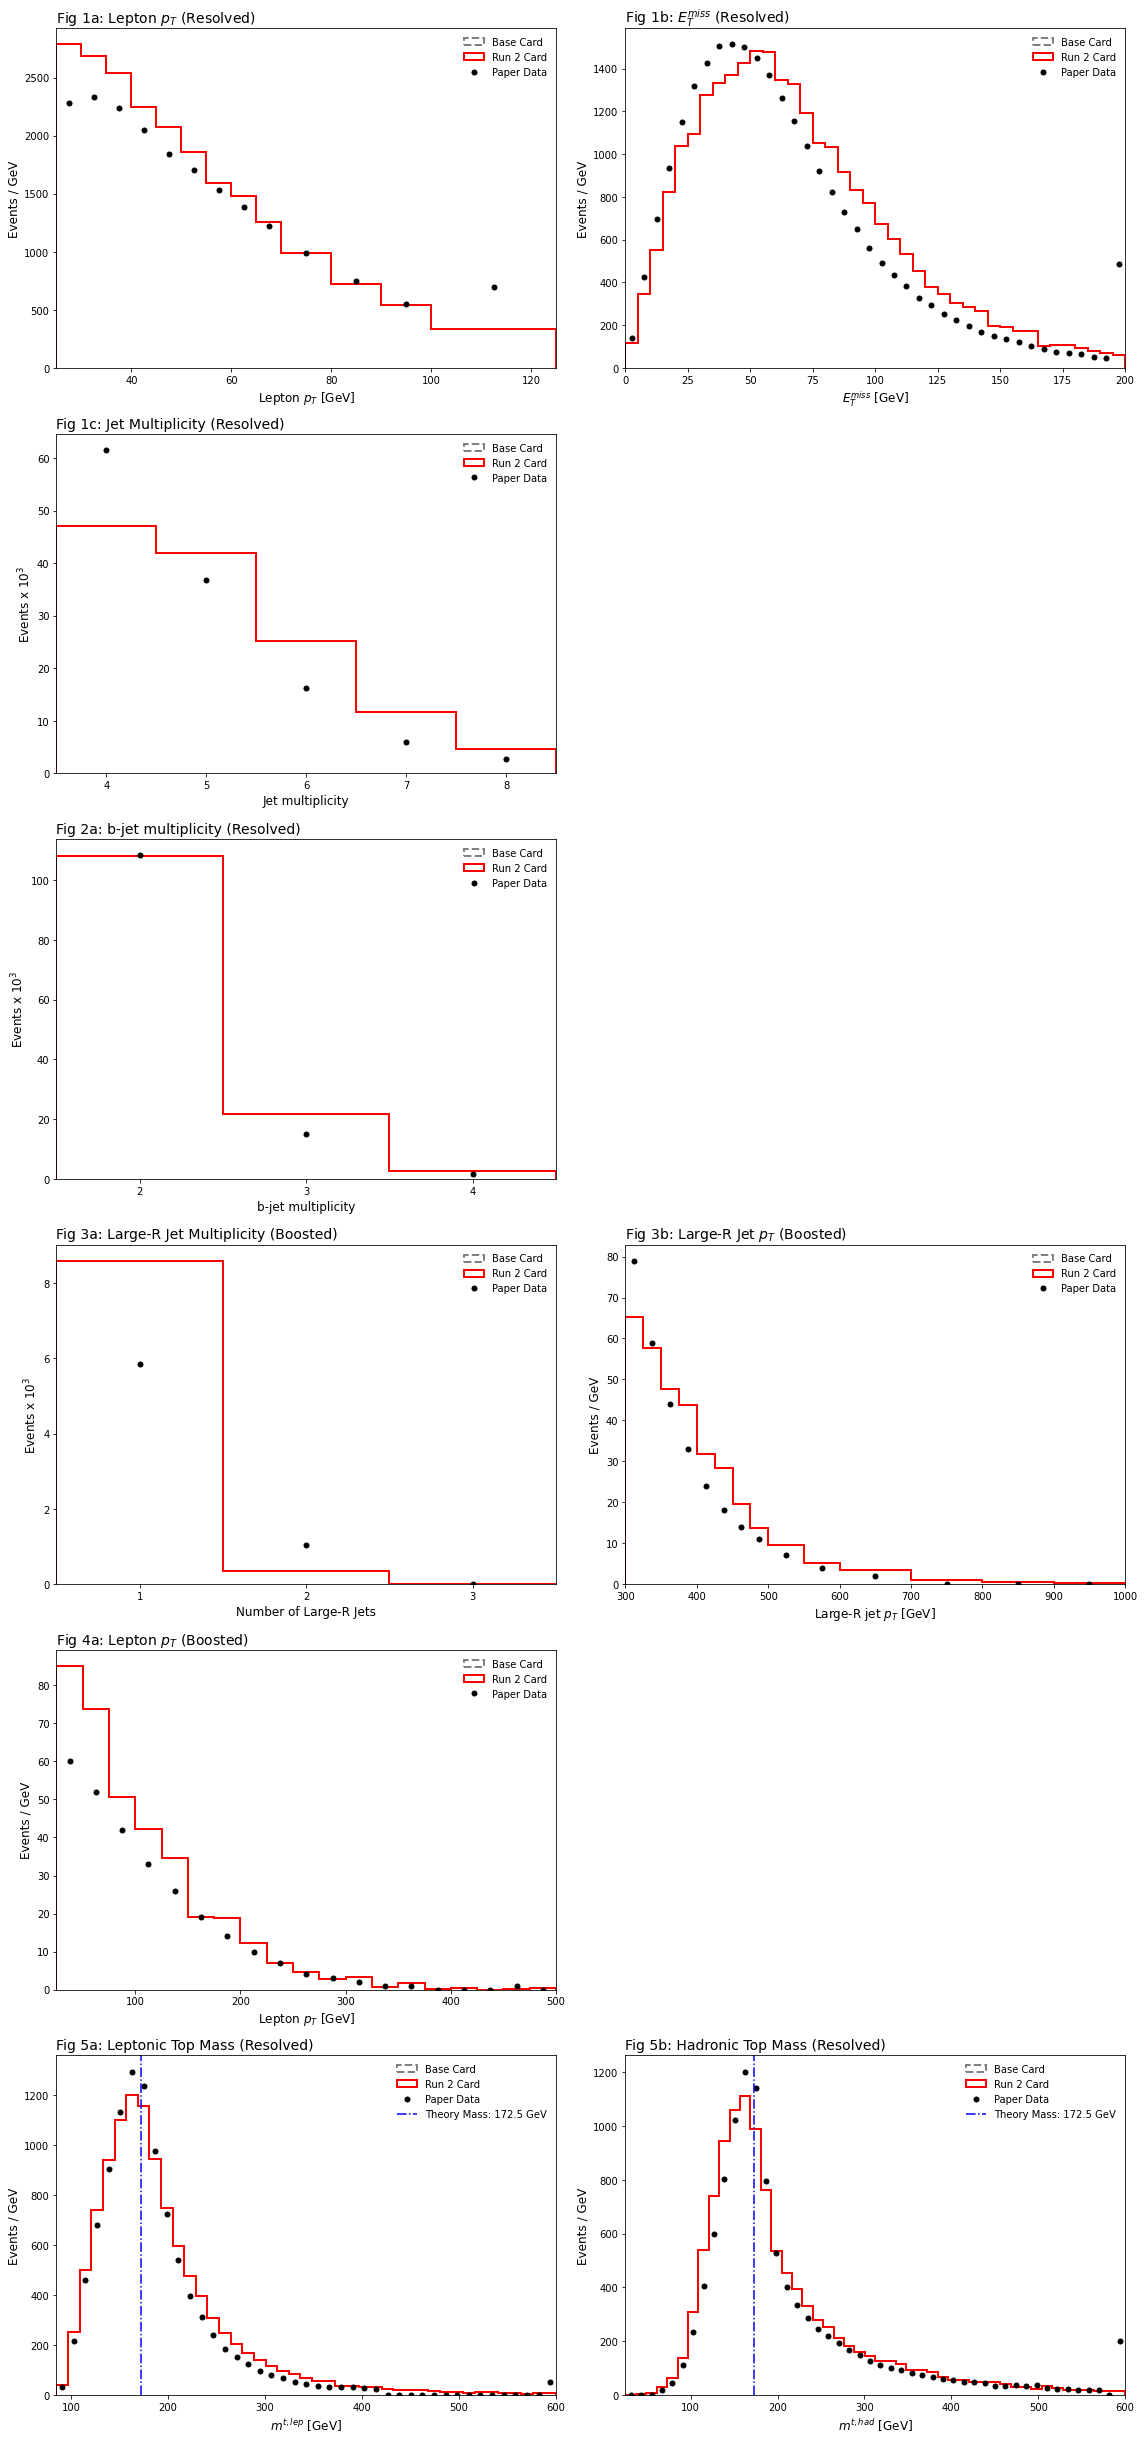

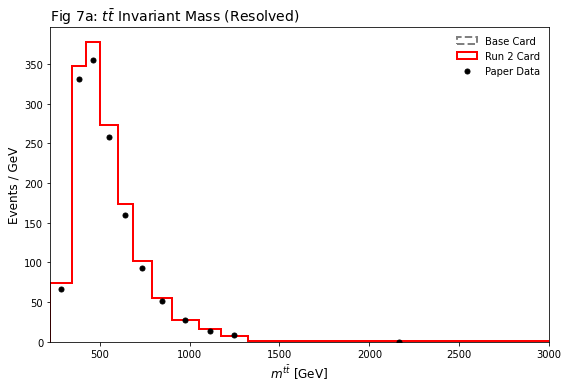

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import os

# ---------------------------------------------------------
# Weights & Normalization
# ---------------------------------------------------------
lumi_pb = 3200.0
xsec_pb = 504.8
# xsec_pb = 831.76
k_factor = 1.65

# NOTE: You will need to provide the initial number of generated events
# for your specific samples. You can grab these from the first row 
# of the cutflow CSVs you are now generating!
base_ngen = 500000  # Replace with actual Initial Raw Batch count for ttbar_default
run2_ngen = 500000  # Replace with actual Initial Raw Batch count for ttbar_run2

# Weight PER EVENT
base_w_val = (lumi_pb * xsec_pb * k_factor) / base_ngen
run2_w_val = (lumi_pb * xsec_pb * k_factor) / run2_ngen

# ---------------------------------------------------------
# CSV Extraction Function for Paper Data
# ---------------------------------------------------------
def read_csv_data(filename):
    """
    Reads the digitized paper data from the CSV.
    Uses column indices:
      3: Left bin edge (x0)
      4: Right bin edge (x1)
      5: Event counts (n_events)
    """
    try:
        df = pd.read_csv(filename)
        df = df.dropna(subset=[df.columns[3], df.columns[4], df.columns[5]])
        
        left_edges = df.iloc[:, 3].values.astype(float)
        right_edges = df.iloc[:, 4].values.astype(float)
        events = df.iloc[:, 5].values.astype(float)
        
        bins = np.append(left_edges, right_edges[-1])
        return bins, events
    except Exception as e:
        print(f"Warning: Could not load {filename}. Exception: {e}")
        return None, None

# ---------------------------------------------------------
# Updated Plotting Function (Variable Bin Width Support)
# ---------------------------------------------------------
def plot_hist(ax, base_data, run2_data, default_bins, range_val, title, xlabel, ylabel, 
              xticks=None, theory_mass=None, scale_weight=1, csv_file=None):
    
    bins = default_bins
    if isinstance(bins, int):
        bins = np.linspace(range_val[0], range_val[1], bins + 1)
    elif isinstance(bins, list):
        bins = np.array(bins)
        
    csv_events = None
    
    if csv_file is not None:
        csv_bins, csv_events = read_csv_data(csv_file)
        if csv_bins is not None:
            bins = csv_bins 
            
    bin_widths = np.diff(bins)
    
    # Drop NaNs just in case to avoid histogram errors
    base_data = base_data.dropna()
    run2_data = run2_data.dropna()
    
    base_counts, _ = np.histogram(base_data, bins=bins)
    run2_counts, _ = np.histogram(run2_data, bins=bins)
    
    base_plot_vals = (base_counts * base_w_val) / bin_widths / scale_weight
    run2_plot_vals = (run2_counts * run2_w_val) / bin_widths / scale_weight
    
    ax.hist(bins[:-1], bins=bins, weights=base_plot_vals, histtype='step', 
            color='gray', linestyle='dashed', linewidth=2, label='Base Card')
    ax.hist(bins[:-1], bins=bins, weights=run2_plot_vals, histtype='step', 
            color='red', linewidth=2, label='Run 2 Card')
    
    if csv_events is not None:
        csv_events_scaled = csv_events / scale_weight
        bin_centers = (bins[:-1] + bins[1:]) / 2
        ax.plot(bin_centers, csv_events_scaled, 'ko', markersize=5, label='Paper Data')
    
    if theory_mass is not None:
        ax.axvline(x=theory_mass, color='blue', linestyle='-.', linewidth=1.5, 
                   label=f'Theory Mass: {theory_mass} GeV')

    ax.set_title(title, fontsize=14, loc='left')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlim(bins[0], bins[-1]) 
    
    if xticks: 
        ax.set_xticks(xticks)
    ax.legend(frameon=False)

# ---------------------------------------------------------
# Load Parquet Data into Pandas DataFrames
# ---------------------------------------------------------
OUTPUT_DIR = "Analysis_Output_TTBAR"

card = "PileUp"  # Change to "PileUp" to load pile-up samples instead

if card == "Default":
    base_tag = "ttbar_default"
    run2_tag = "ttbar_run2"
elif card == "PileUp":
    base_tag = "ttbar_pu"
    run2_tag = "ttbar_pu_run2"

# Load Resolved
base_res = ak.to_dataframe(ak.from_parquet(os.path.join(OUTPUT_DIR, "Resolved", f"{base_tag}.parquet")))
run2_res = ak.to_dataframe(ak.from_parquet(os.path.join(OUTPUT_DIR, "Resolved", f"{run2_tag}.parquet")))

print(base_res.head())

# Load Boosted
base_bst = ak.to_dataframe(ak.from_parquet(os.path.join(OUTPUT_DIR, "Boosted", f"{base_tag}.parquet")))
run2_bst = ak.to_dataframe(ak.from_parquet(os.path.join(OUTPUT_DIR, "Boosted", f"{run2_tag}.parquet")))

# ---------------------------------------------------------
# Master Plotting Execution
# ---------------------------------------------------------
fig, axs = plt.subplots(6, 2, figsize=(16, 34))

# --- FIGURE 1: Resolved Kinematics ---
plot_hist(axs[0,0], base_res['lep_pt'], run2_res['lep_pt'], default_bins=25, range_val=(0, 125), 
          title="Fig 1a: Lepton $p_T$ (Resolved)", xlabel="Lepton $p_T$ [GeV]", ylabel="Events / GeV",
          csv_file="SPP ttbar - Lepton pT (res).csv")

plot_hist(axs[0,1], base_res['met'], run2_res['met'], default_bins=40, range_val=(0, 200), 
          title="Fig 1b: $E_T^{miss}$ (Resolved)", xlabel="$E_T^{miss}$ [GeV]", ylabel="Events / GeV",
          csv_file="SPP ttbar - MET (res).csv")

plot_hist(axs[1,0], base_res['n_jets'], run2_res['n_jets'], default_bins=[3.5, 4.5, 5.5, 6.5, 7.5, 8.5], range_val=(3.5, 8.5), 
          title="Fig 1c: Jet Multiplicity (Resolved)", xlabel="Jet multiplicity", ylabel="Events x $10^3$", xticks=[4,5,6,7,8], scale_weight=1000,
          csv_file="SPP ttbar - Jet Multiplicity (res).csv")

# MISSING FROM NEW OUTPUT SCHEMA
# plot_hist(axs[1,1], base_res['jet_pt'], run2_res['jet_pt'], default_bins=30, range_val=(0, 150), 
#           title="Fig 1d: Jet $p_T$ (Resolved)", xlabel="Jet $p_T$ [GeV]", ylabel="Events / GeV x $10^3$", scale_weight=1000,
#           csv_file="SPP ttbar - Jet pT (res).csv")
axs[1,1].axis('off') # Hide empty plot

# --- FIGURE 2: Resolved b-jets ---
plot_hist(axs[2,0], base_res['n_bjets'], run2_res['n_bjets'], default_bins=[1.5, 2.5, 3.5, 4.5], range_val=(1.5, 4.5), 
          title="Fig 2a: b-jet multiplicity (Resolved)", xlabel="b-jet multiplicity", ylabel="Events x $10^3$", xticks=[2,3,4], scale_weight=1000,
          csv_file="SPP ttbar - b-jet multiplicity.csv")

# MISSING FROM NEW OUTPUT SCHEMA
# plot_hist(axs[2,1], base_res['lead_bjet_eta'], run2_res['lead_bjet_eta'], default_bins=25, range_val=(-2.5, 2.5), 
#           title="Fig 2b: Leading b-jet $\eta$ (Resolved)", xlabel="Leading b-jet $\eta$", ylabel="Events / Unit $\eta$ x $10^3$", scale_weight=1000,
#           csv_file="SPP ttbar - Leading b-jet eta.csv")
axs[2,1].axis('off')

# --- FIGURE 3: Boosted Large-R Jets ---
plot_hist(axs[3,0], base_bst['n_fatjets'], run2_bst['n_fatjets'], default_bins=[0.5, 1.5, 2.5, 3.5], range_val=(0.5, 3.5), 
          title="Fig 3a: Large-R Jet Multiplicity (Boosted)", xlabel="Number of Large-R Jets", ylabel="Events x $10^3$", xticks=[1,2,3], scale_weight=1000,
          csv_file="SPP ttbar - N-LargeRjets.csv")

plot_hist(axs[3,1], base_bst['lead_fj_pt'], run2_bst['lead_fj_pt'], default_bins=35, range_val=(300, 1000), 
          title="Fig 3b: Large-R Jet $p_T$ (Boosted)", xlabel="Large-R jet $p_T$ [GeV]", ylabel="Events / GeV",
          csv_file="SPP ttbar - pt-LargeRjets.csv")

# --- FIGURE 4: Boosted Kinematics ---
plot_hist(axs[4,0], base_bst['lep_pt'], run2_bst['lep_pt'], default_bins=25, range_val=(0, 500), 
          title="Fig 4a: Lepton $p_T$ (Boosted)", xlabel="Lepton $p_T$ [GeV]", ylabel="Events / GeV",
          csv_file="SPP ttbar - Lepton pT (bost).csv")

# MISSING FROM NEW OUTPUT SCHEMA
# plot_hist(axs[4,1], base_bst['lep_eta'], run2_bst['lep_eta'], default_bins=25, range_val=(-2.5, 2.5), 
#           title="Fig 4b: Lepton $\eta$ (Boosted)", xlabel="Lepton $\eta$", ylabel="Events / Unit $\eta$ x $10^3$", scale_weight=1000,
#           csv_file="SPP ttbar - Lepton eta(bost).csv")
axs[4,1].axis('off')

# --- FIGURE 5: Resolved Reconstruction Masses ---
plot_hist(axs[5,0], base_res['m_t_lep'], run2_res['m_t_lep'], default_bins=30, range_val=(0, 600), 
          title="Fig 5a: Leptonic Top Mass (Resolved)", xlabel="$m^{t,lep}$ [GeV]", ylabel="Events / GeV", theory_mass=172.5,
          csv_file="SPP ttbar - m_t_lep.csv")

plot_hist(axs[5,1], base_res['m_t_had'], run2_res['m_t_had'], default_bins=30, range_val=(0, 600), 
          title="Fig 5b: Hadronic Top Mass (Resolved)", xlabel="$m^{t,had}$ [GeV]", ylabel="Events / GeV", theory_mass=172.5,
          csv_file="SPP ttbar - m_t_had.csv")

plt.tight_layout()
plt.show()

# --- FIGURE 7: m_tt (Separate Figure Block) ---
fig_tt, ax_tt = plt.subplots(1, 1, figsize=(8, 5.5))
plot_hist(ax_tt, base_res['m_tt'], run2_res['m_tt'], default_bins=30, range_val=(0, 3000), 
          title="Fig 7a: $t\\bar{t}$ Invariant Mass (Resolved)", xlabel="$m^{t\\bar{t}}$ [GeV]", ylabel="Events / GeV",
          csv_file="SPP ttbar - m_tt.csv")

plt.tight_layout()
plt.show()